<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
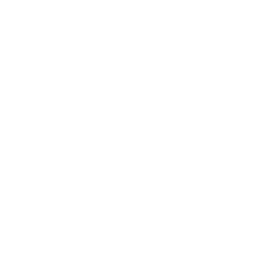
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">正準判別分析による顧客リスクプロファイリング</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 金融サービス / 信用リスク分析 &nbsp;|&nbsp; 2026年3月</p>
</div>
</div>
</div>

## エグゼクティブサマリー

消費者向け住宅ローンポートフォリオにおける3つのローン状態グループ — **デフォルト（債務不履行）**、**正常（継続中）**、**繰上返済済** — は、複数の財務健全性の次元に沿って同時に異なっており、そのためどの単一の比率も弱いリスクシグナルにしかなりません。本ノートブックでは、100人の顧客からなるリスクレビューサンプルに **PROC CANDISC**（正準判別分析）を適用し、相関する6つの財務比率を、3つの状態グループ間の分離を最大化する2つの正準次元へと凝縮します。

第1正準次元はグループ間分離のほとんどすべてを担っており — 正準相関 **0.958**、その分散の **91.8%** をグループ所属と共有 — 借り手を一方の端のデフォルトから他方の端の繰上返済済まできれいに順序付けます。第2次元（正準相関 **0.503**、二乗値 **0.254**）は、延滞履歴とレバレッジが主導する副次的なコントラストを加えます。二乗マハラノビス距離は、**DEFAULT** と **PREPAID** の重心が最も大きく離れたペア（**75.3**）であり、**CURRENT** がその中間に位置する（DEFAULT から 34.3、PREPAID から 10.1）ことを確認します。結果として得られる正準スコアは、ポートフォリオのセグメンテーションおよびスコアカードのキャリブレーションに適したコンパクトな複合リスク指標を形成します。

## データソース

| ソース | 説明 | レコード数 |
|--------|-------------|--------|
| WORK.LOAN_PROFILES | ローン状態でラベル付けされ、バランスの取れたリスクレビューサンプルとして抽出された、合成の顧客財務比率および行動指標 | 100 |

このサンプルは、判別分析のために各状態グループが安定したグループ内共分散構造を推定できるだけの十分な大きさになるよう、デフォルトおよび繰上返済済の口座を意図的に過大に代表させています（ケース・コントロール型の抽出）。

---

In [1]:
/* --------------------------------------------------------
   融資顧客のリスクレビュー用の合成サンプルを生成する。
   3つのステータス群（DEFAULT / CURRENT / PREPAID）をリスクの
   両裾に向けてオーバーサンプリングし、各クラスが群内共分散を
   安定して推定できる十分な大きさになるようにする。
   -------------------------------------------------------- */
データ work.loan_profiles;
    呼出 streaminit(42);
    長さ loan_status $10 vintage $7 customer_id $12;
    配列 statuses[3] $10 _temporary_ ('DEFAULT' 'CURRENT' 'PREPAID');
    配列 vintages[4] $7 _temporary_ ('2022-Q1' '2022-Q3' '2023-Q1' '2023-Q3');
    繰返 i = 1 から 20000;
        customer_id = cat('CUST-', PUT(i, z6.));
        vintage = vintages[int(rand('uniform') * 4) + 1];
        status_prob = rand('uniform');
        もし status_prob < 0.30 なら status_idx = 1;       /* DEFAULT */
        他 もし status_prob < 0.70 なら status_idx = 2;  /* CURRENT */
        他 status_idx = 3;                             /* PREPAID */
        loan_status = statuses[status_idx];
        /* 財務比率が3つのステータス群を分離する */
        もし loan_status = 'DEFAULT' なら 繰返;
            dti_ratio          = rand('normal', 0.58, 0.12);
            ltv_ratio          = rand('normal', 0.92, 0.10);
            payment_to_income  = rand('normal', 0.42, 0.08);
            credit_utilization = rand('normal', 0.85, 0.10);
            months_delinquent  = int(rand('exponential') * 4) + 1;
            savings_balance    = rand('exponential') * 4000 + 200;
        終了;
        他 もし loan_status = 'CURRENT' なら 繰返;
            dti_ratio          = rand('normal', 0.35, 0.10);
            ltv_ratio          = rand('normal', 0.78, 0.09);
            payment_to_income  = rand('normal', 0.28, 0.07);
            credit_utilization = rand('normal', 0.45, 0.15);
            months_delinquent  = 0;
            savings_balance    = rand('exponential') * 8000 + 200;
        終了;
        他 繰返;
            dti_ratio          = rand('normal', 0.22, 0.07);
            ltv_ratio          = rand('normal', 0.60, 0.12);
            payment_to_income  = rand('normal', 0.20, 0.05);
            credit_utilization = rand('normal', 0.25, 0.12);
            months_delinquent  = 0;
            savings_balance    = rand('exponential') * 16000 + 500;
        終了;
        /* 比率を丸め、妥当な範囲に制約する */
        dti_ratio          = round(dti_ratio, 0.001);
        ltv_ratio          = round(ltv_ratio, 0.001);
        payment_to_income  = round(payment_to_income, 0.001);
        credit_utilization = round(credit_utilization, 0.001);
        savings_balance    = round(savings_balance, 0.01);
        もし dti_ratio < 0.05 なら dti_ratio = 0.05;
        もし dti_ratio > 0.99 なら dti_ratio = 0.99;
        もし ltv_ratio < 0.10 なら ltv_ratio = 0.10;
        もし ltv_ratio > 1.20 なら ltv_ratio = 1.20;
        もし credit_utilization < 0.01 なら credit_utilization = 0.01;
        もし credit_utilization > 0.99 なら credit_utilization = 0.99;
        出力;
    終了;
    削除 i status_prob status_idx;
実行;


NOTE: DATA work.loan_profiles

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.loan_profiles (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  7.05 seconds
  cpu   7.05 seconds


---

### グループの基本プロファイル

比率を凝縮する前に、3つの状態グループが1変数ずつどのように異なるかを要約し、組成年度（ヴィンテージ）間でサンプル構成を確認します。

                                                   ローンステータス別の財務比率サマリー                                                   

                                                  The MEANS Procedure

                                        Analysis Variable : dti_ratio DTI比率

        ローンステータス                          N Obs           Mean        Std Dev
        ---------------------------------------------------------------------
        CURRENT                              46          0.331          0.112
        DEFAULT                              29          0.570          0.114
        PREPAID                              25          0.216          0.056
        ---------------------------------------------------------------------

                                        Analysis Variable : ltv_ratio LTV比率

        ローンステータス                          N Obs           Mean        Std Dev
        ---------------------------------------------------------------------
        CURRENT             


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_vintage_loan_status.spec.json
NOTE: PROC FREQ statement used.


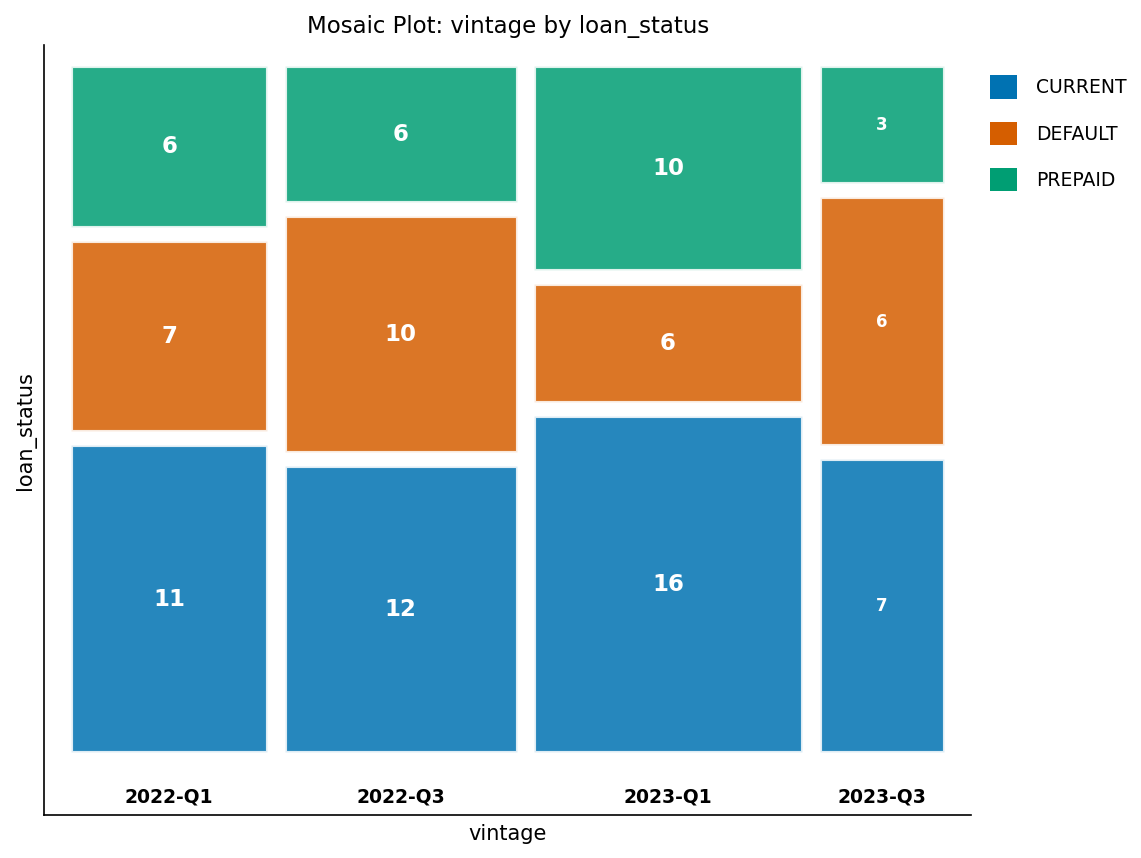

In [2]:
/* --------------------------------------------------------
   ローンステータス別の財務比率のベースライン分布
   -------------------------------------------------------- */
処理 平均 データ=work.loan_profiles n mean std maxdec=3;
    分類 loan_status;
    変数 dti_ratio ltv_ratio payment_to_income credit_utilization
        savings_balance months_delinquent;
    見出 loan_status='ローンステータス'
          dti_ratio='DTI比率' ltv_ratio='LTV比率'
          payment_to_income='返済負担率' credit_utilization='与信利用率'
          savings_balance='貯蓄残高' months_delinquent='延滞月数';
    表題 'ローンステータス別の財務比率サマリー';
実行;

/* --------------------------------------------------------
   ヴィンテージとステータス別のサンプル構成
   -------------------------------------------------------- */
処理 度数 データ=work.loan_profiles;
    TABLES vintage * loan_status / nocum nopercent;
    見出 vintage='ヴィンテージ' loan_status='ローンステータス';
    表題 'ヴィンテージ×ステータス別のサンプル構成';
実行;

---

### 正準判別分析

全100人の顧客にわたって、1つのプールされた正準判別モデルを当てはめます。`OUT=` は顧客ごとの正準スコアを書き出し、`OUTSTAT=` は正準構造、クラス重心、および二乗マハラノビス距離を取得し、`DISTANCE` はグループ間距離を要求します。ここで宣伝されているプロシージャは、まさに実行されるものと同一です — **PROC CANDISC**。

                                                  ヴィンテージ×ステータス別のサンプル構成                                                  




NOTE: ODS OUTPUT: CANONICALCORRELATIONS -> can_corr
NOTE: PROC CANDISC data=work.loan_profiles ncan=Some(2) prefix=Can

NOTE: Using Python/scikit-learn for canonical discriminant analysis
NOTE: Number of Observations: 100
NOTE: Number of Classes: 3
NOTE: Class Level Information:
NOTE:   CURRENT: 46
NOTE:   DEFAULT: 29
NOTE:   PREPAID: 25
NOTE: Canonical Correlations:
NOTE:   Can1: 0.958136
NOTE:   Can2: 0.503509
NOTE: Eigenvalues of Inv(E)*H:
NOTE:                          Canonical  Approximate  Squared
NOTE:               Eigenvalue Correlation  Std Error Correlation
NOTE:   Can1       11.198645    0.958136            0.918024
NOTE:   Can2        0.339624    0.503509            0.253522
NOTE: Multivariate Statistics and F Approximations:
NOTE:   Statistic                Value     F Value  Num DF  Den DF  Pr > F
NOTE:   Wilks' Lambda         0.061194     46.65      12   184.0   0.0000
NOTE:   Pillai's Trace        1.171545     21.68      12   184.0   0.0000
NOTE:   Hotelling-Lawley  

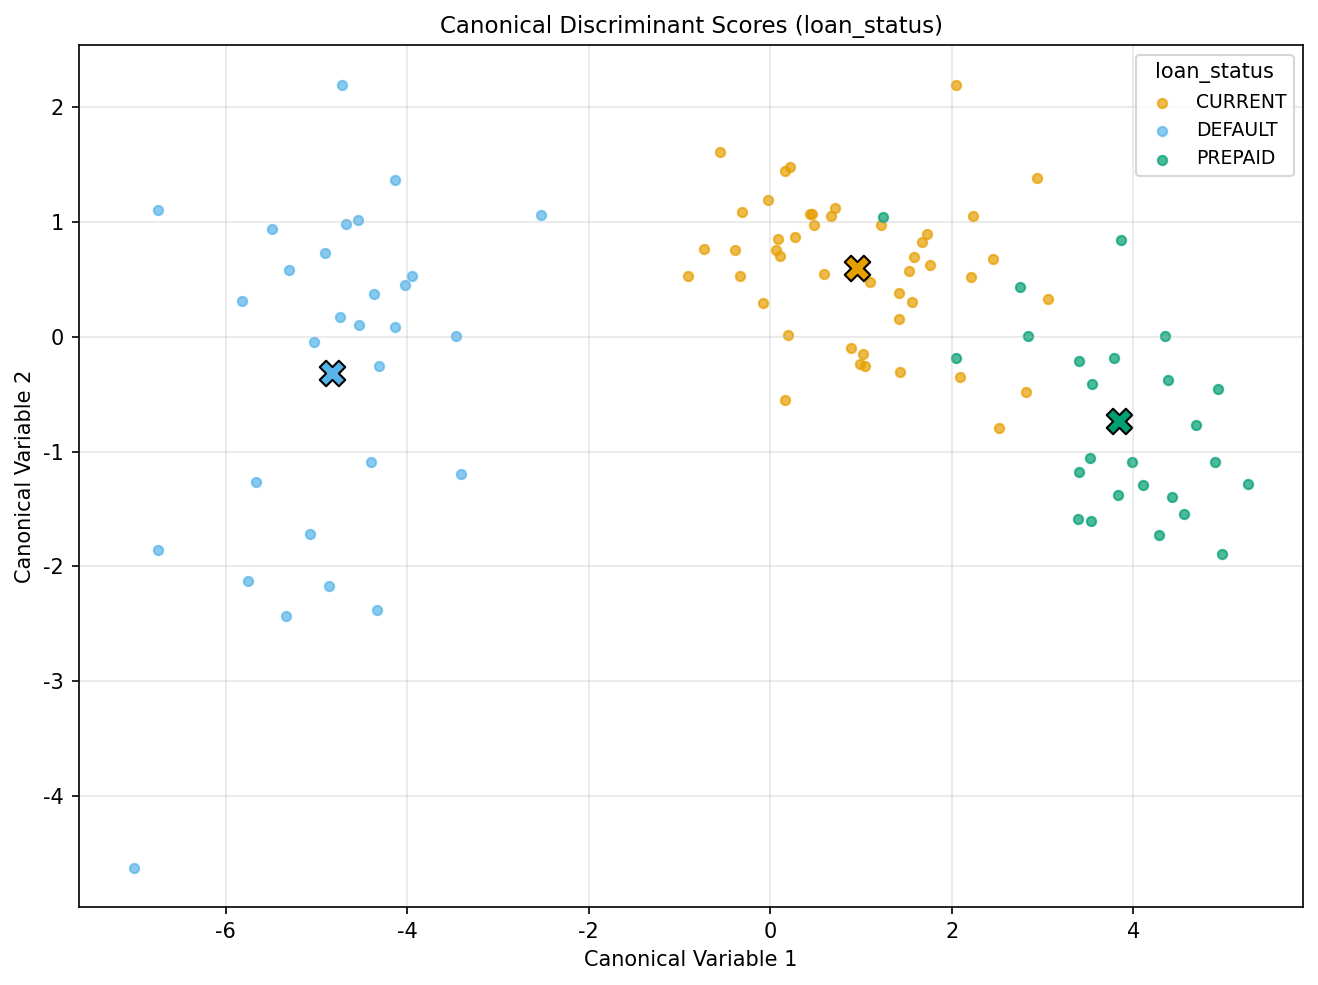

In [3]:
/* --------------------------------------------------------
   ローンステータス群の正準判別分析。
   OUT=    顧客ごとの正準スコア（Can1, Can2）
   OUTSTAT= 構造、クラス平均、マハラノビス距離
   -------------------------------------------------------- */
ODS 出力 CanonicalCorrelations=work.can_corr;

処理 CANDISC データ=work.loan_profiles
    out=work.risk_scores
    OUTSTAT=work.can_stat
    ncan=2
    distance;
    分類 loan_status;
    変数 dti_ratio ltv_ratio payment_to_income credit_utilization
        savings_balance months_delinquent;
    見出 loan_status='ローンステータス'
          dti_ratio='DTI比率' ltv_ratio='LTV比率'
          payment_to_income='返済負担率' credit_utilization='与信利用率'
          savings_balance='貯蓄残高' months_delinquent='延滞月数';
    表題 'ローンステータス群の正準リスク判別';
実行;

ODS 出力 CLOSE;

---

### 正準相関

各正準次元が3つのグループ間の分離のどれだけを捕らえているか。

In [4]:
処理 印刷 データ=work.can_corr noobs;
    表題 '正準相関';
実行;

                                                          正準相関                                                          

CANONICAL_VARIABLE  CANONICAL_CORRELATION  SQUARED_CANONICAL_CORRELATION     EIGENVALUE
Can1                         0.9581355246                   0.9180236835  11.1986452089
Can2                          0.503509317                   0.2535216323   0.3396235488




NOTE: PROC PRINT data=work.can_corr

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


### 正準構造（変数の負荷量）

各元の財務比率と2つの正準次元との相関 — これが各次元を解釈する方法です。

In [5]:
処理 印刷 データ=work.can_stat noobs;
    条件 _type_ = 'STRUCTUR';
    変数 _name_ Can1 Can2;
    表題 'プールされた群内正準構造';
実行;

                                                      プールされた群内正準構造                                                      

            _NAME_       CAN1       CAN2
dti_ratio           -0.403583  -0.022755
ltv_ratio           -0.369749   0.732657
payment_to_income   -0.304192   0.117008
credit_utilization  -0.595076  -0.056264
savings_balance       0.12558   0.093182
months_delinquent   -0.323965  -0.699884




NOTE: PROC PRINT data=work.can_stat

NOTE: PROC PRINT completed: 6 observations printed, 3 variables


### グループ重心とマハラノビス距離

正準軸上のクラス平均（グループ重心）と、各グループペア間の二乗マハラノビス距離 — リスクスコアのキャリブレーションの基礎となります。

In [6]:
処理 印刷 データ=work.can_stat noobs;
    条件 _type_ IN ('CANMEAN' 'DIST');
    変数 _type_ _name_ Can1 Can2;
    表題 '群重心（CANMEAN）と平方マハラノビス距離（DIST）';
実行;

                                             群重心（CANMEAN）と平方マハラノビス距離（DIST）                                              

 _TYPE_              _NAME_       CAN1       CAN2
CANMEAN  CURRENT              0.956102    0.59917
CANMEAN  DEFAULT             -4.826727  -0.316237
CANMEAN  PREPAID              3.839776  -0.735639
DIST     CURRENT to DEFAULT  34.279058          .
DIST     CURRENT to PREPAID  10.097273          .
DIST     DEFAULT to PREPAID  75.284092          .




NOTE: PROC PRINT data=work.can_stat

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


---

### 正準判別マップ

各顧客を2次元の正準空間上にプロットし、ローン状態で色分けしています。よく分離されたクラスターは、正準スコアが強いグループ情報を担っていることを示します。

                                             群重心（CANMEAN）と平方マハラノビス距離（DIST）                                              




NOTE: PROC SGPLOT data=work.risk_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


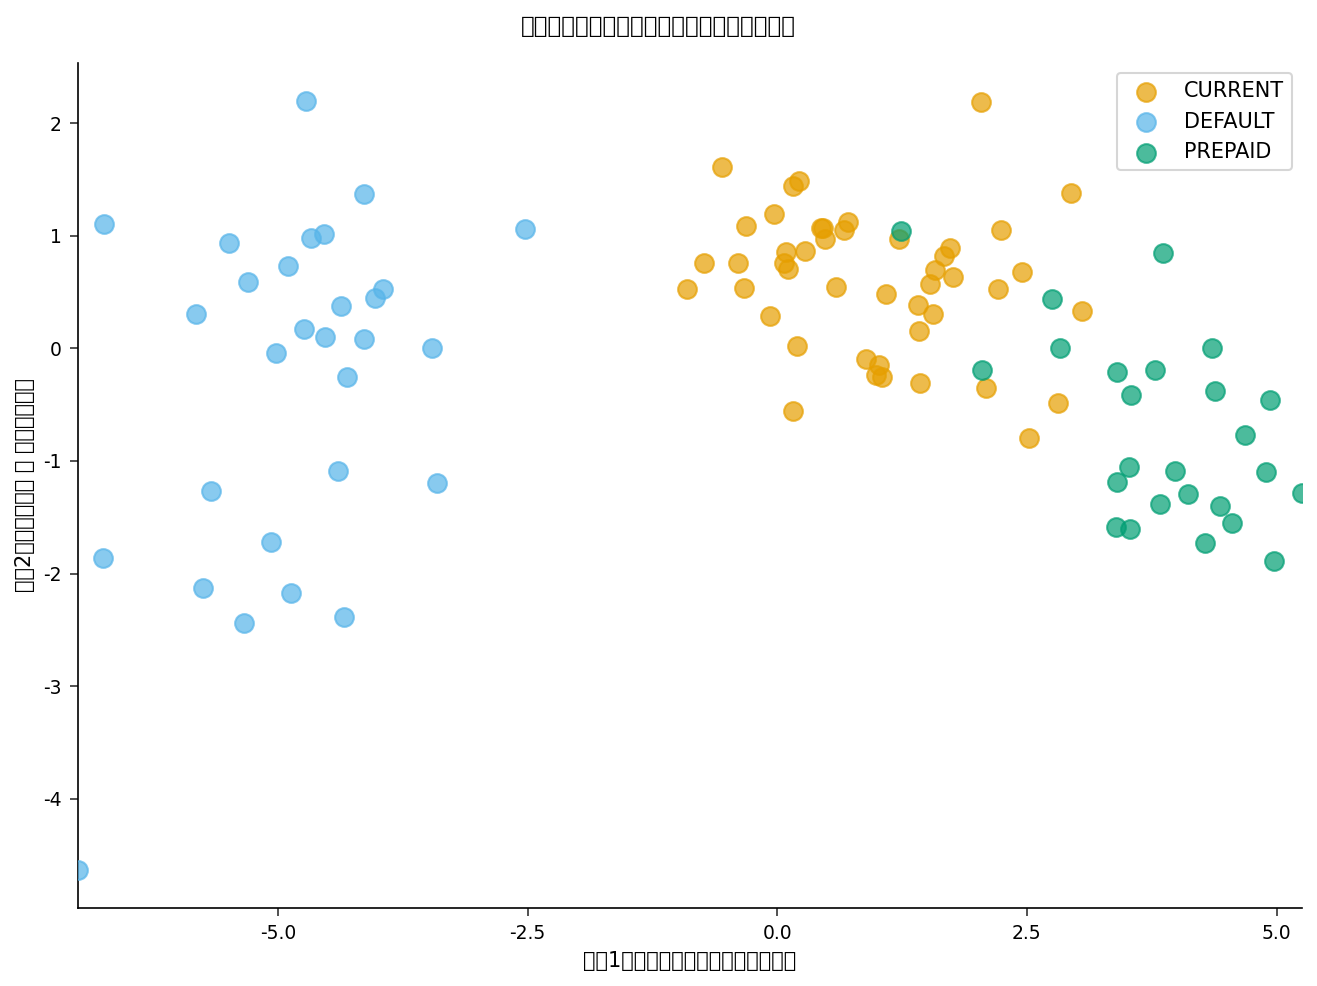

In [7]:
処理 SGPLOT データ=work.risk_scores;
    SCATTER x=Can1 y=Can2 / GROUP=loan_status
        MARKERATTRS=(SYMBOL=circlefilled size=9)
        TRANSPARENCY=0.3;
    XAXIS 見出='正準1（デフォルトリスクの重大度）';
    YAXIS 見出='正準2（期限前返済 対 レバレッジ）';
    表題 '顧客リスクプロファイリング：正準判別空間';
実行;

---

### 解釈

2つの正準次元は、この100人の顧客サンプル（正常46人、デフォルト29人、繰上返済済25人）の中で、3つのローン状態グループを鋭く分離します。

**次元1 — デフォルトリスクの深刻度（正準相関 0.958、共有分散 91.8%）。** この軸だけでグループ分離の圧倒的大部分を占めます（固有値は11.20、第2軸は0.34）。プールされたクラス内正準構造において、この軸はクレジット利用率（-0.595）、債務対所得比（-0.404）、LTV（-0.370）、延滞月数（-0.324）、支払対所得比（-0.304）に最も強く負荷し — すべてのレバレッジおよび負担の指標が同じ方向を指しています。負荷量が負であるため、低い（より負の）Can1 スコアが最も高リスクの借り手を示します。クラス重心はこれを裏付けます。デフォルト口座は Can1 = -4.83、正常口座は +0.96、繰上返済済口座は +3.84 に位置し、最悪から最良の信用健全性まできれいな単調順序をなしています。

**次元2 — レバレッジ対延滞（正準相関 0.503）。** 第2軸は LTV 比率（+0.733）と延滞月数（-0.700）を対比させます。高レバレッジだが正常な借り手と、延滞を抱える借り手とを分離します。Can1 内の描像を精緻化しますが、分離への寄与ははるかに小さく、これは正常グループ（正常 +0.599、繰上返済済 -0.736）のほぼ等しい Can2 重心が示すとおりです。

**グループ分離。** クラス平均間の二乗マハラノビス距離はギャップを定量化します。DEFAULT から PREPAID が 75.3 で最大、DEFAULT から CURRENT が 34.3、CURRENT から PREPAID が 10.1 で最小です。したがって、2つの正常グループは互いに、デフォルトグループとのいずれの距離よりも近く、まさに貸し手が予想するとおりです。

**実務上の利用。** 第1正準スコアは、すぐに使える複合リスク指標のように振る舞います。相関する6つの比率を、顧客を最高から最低のデフォルトリスクへと順序付ける、よく分離された1つの次元へと圧縮します。ポートフォリオチームは Can1 のカットポイントでセグメント化でき、マハラノビス距離は、スコアカードのキャリブレーション時に新規申込者を最も近い状態グループへ割り当てるための原理に基づいた基礎を与えます。

---

### スコアリングエンジンへのエクスポート

顧客ごとの正準スコアと、（重心とマハラノビス距離を含む）正準統計量データセットを、下流のスコアカードキャリブレーションのために永続化します。

In [8]:
/* --------------------------------------------------------
   正準リスクスコアと正準統計量をエクスポートする
   -------------------------------------------------------- */
処理 EXPORT データ=work.risk_scores
    OUTFILE='customer_risk_canonical_scores.csv'
    DBMS=csv REPLACE;
実行;

処理 EXPORT データ=work.can_stat
    OUTFILE='canonical_statistics.csv'
    DBMS=csv REPLACE;
実行;


NOTE: PROC EXPORT data=work.risk_scores outfile=customer_risk_canonical_scores.csv

NOTE: Exported 100 rows to customer_risk_canonical_scores.csv.
NOTE: PROC EXPORT data=work.can_stat outfile=canonical_statistics.csv

NOTE: Exported 31 rows to canonical_statistics.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 機密
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
提供元 <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>